[2026-07-08 15:11:18] [info     ] 计算因子，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[AI001] main_enter | elapsed=0.0s | rss_peak_mb=200.91 | start_date=2024-01-01 00:00:00 | end_date=2024-12-31 23:59:59
[AI001] imports_start | elapsed=0.0s | rss_peak_mb=200.91
[AI001] xgboost_import_start | elapsed=0.0s | rss_peak_mb=200.91
[AI001] imports_done | elapsed=0.66s | rss_peak_mb=268.92 | xgboost_version=1.7.3
[AI001] train_window_resolved | elapsed=0.66s | rss_peak_mb=268.92 | train_start=2021-01-01 00:00:00 | train_end=2023-12-31 00:00:00
[AI001] train_features_start | elapsed=0.66s | rss_peak_mb=268.92
[AI001] feature_chunks_start | elapsed=0.66s | rss_peak_mb=268.92 | phase=train | table=bigalpha_2026_stock_bar1m | start=2021-01-01 00:00:00 | end=2023-12-31 23:59:59
[AI001] feature_chunk_query_start | elapsed=0.66s | rss_peak_mb=268.92 | phase=train | chunk=1 | start=2021-01-01 00:00:00 | end=2021-01-31 23:59:59
[AI001] feature_chunk_query_done | elapsed=5.74s | rss_peak_mb=2463.51 | pha

时段,IC
2024-01-15~2024-02-08,-0.0083
2024-09-24~2024-10-08,0.0695

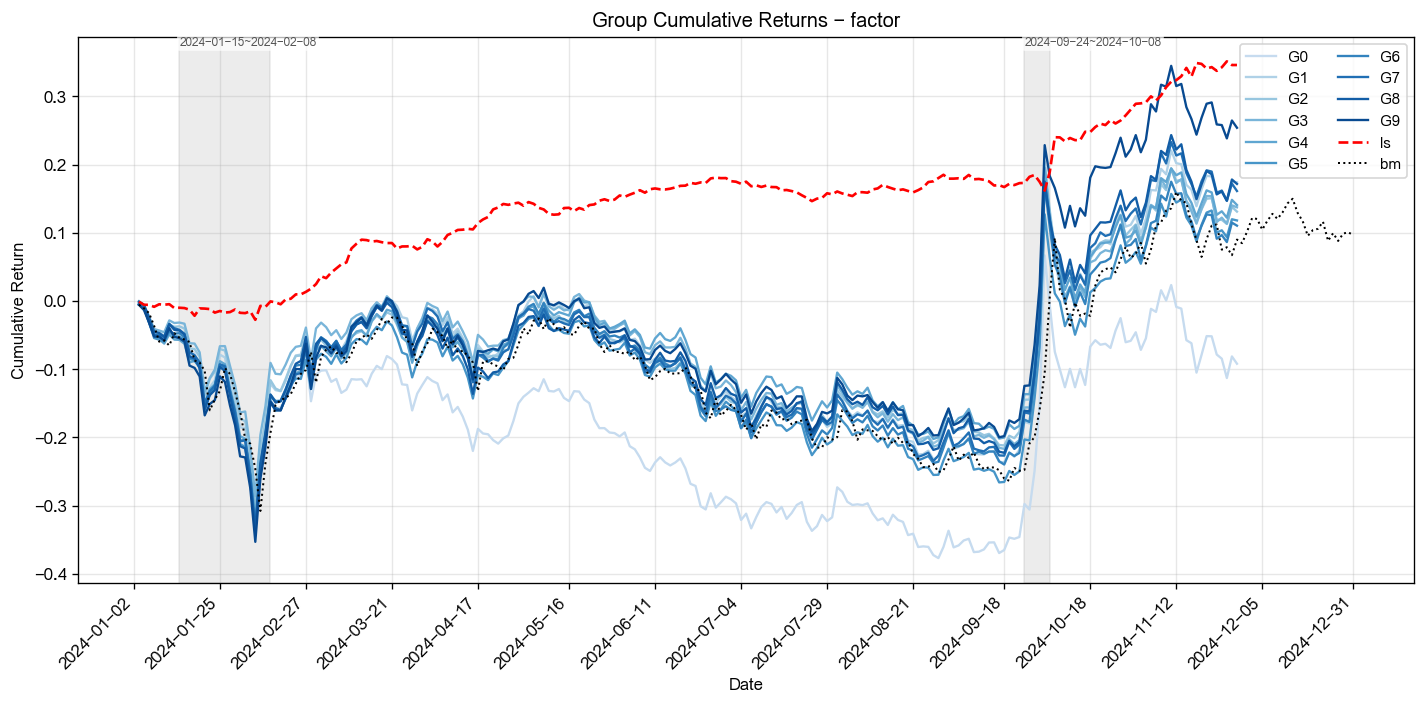
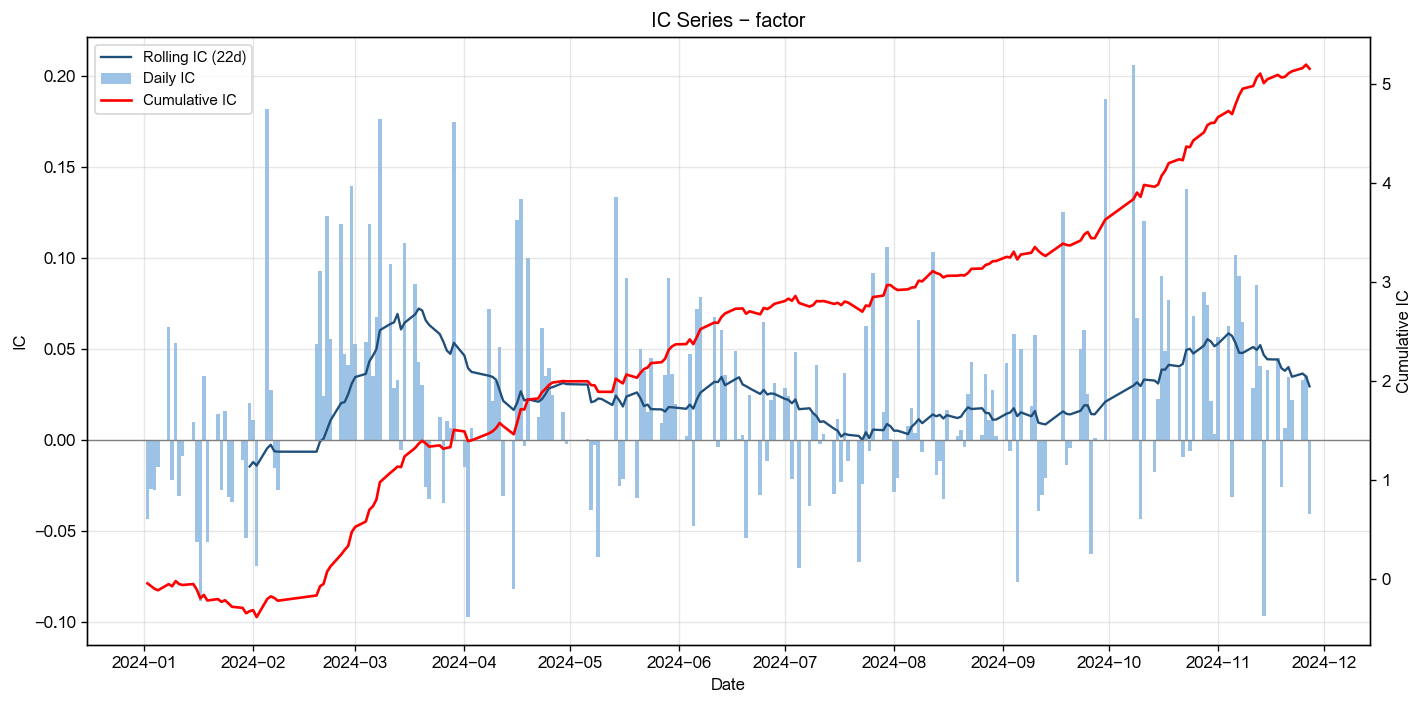
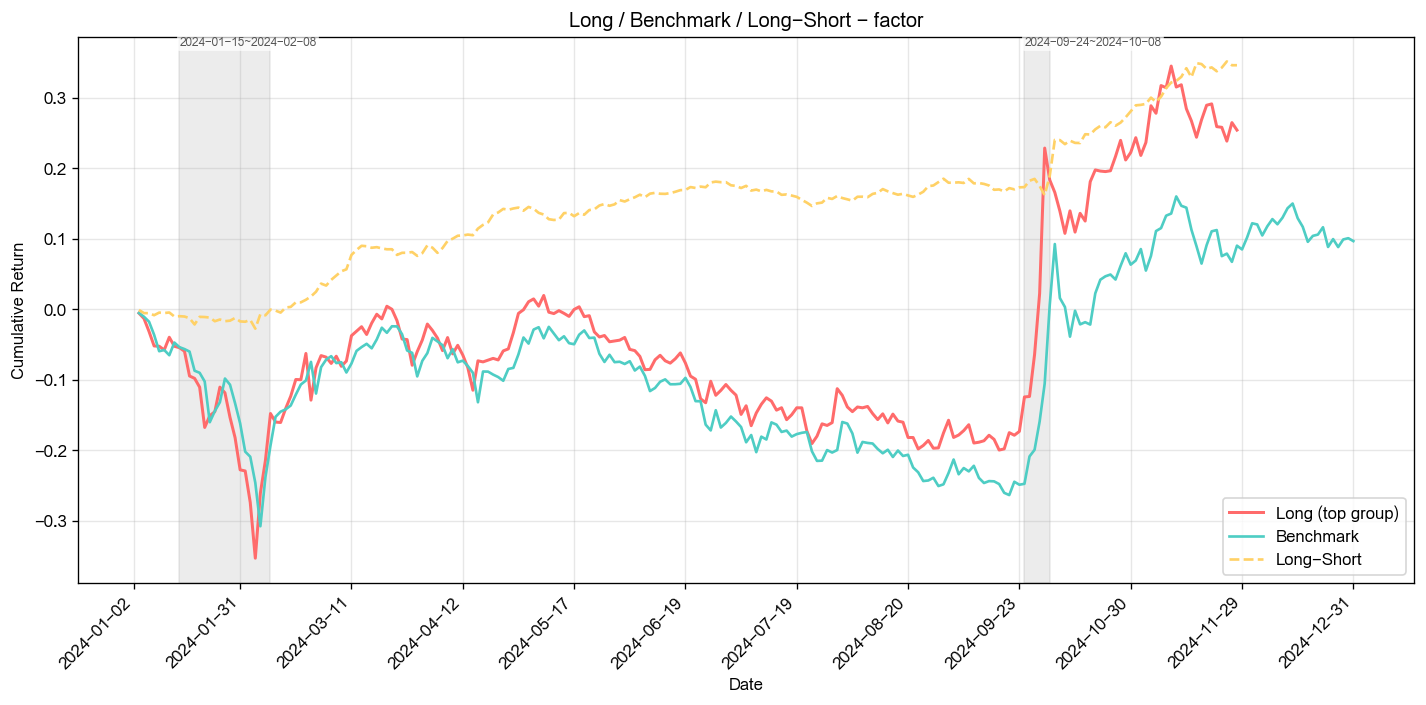
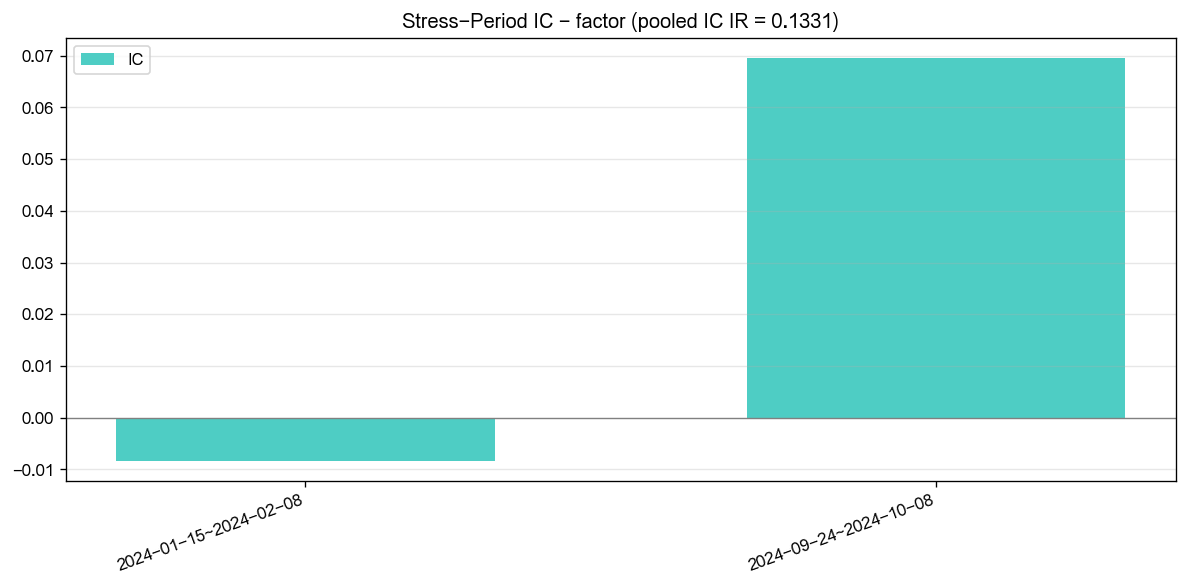
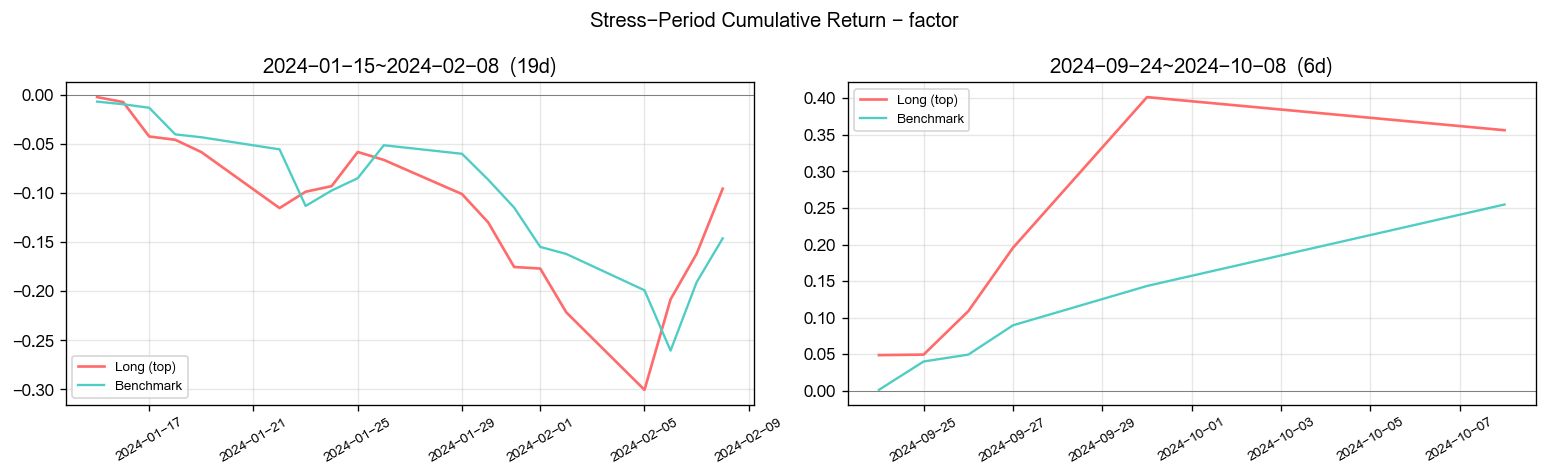

[2026-07-08 15:25:07] [info     ] ========== 因子池回归 ==========
[2026-07-08 15:25:07] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-08 15:25:10] [info     ] 获取收益率数据, 耗时: 3.8483 秒
[2026-07-08 15:25:11] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.012 秒
[2026-07-08 15:25:11] [info     ] 统计 回归结果, 耗时: 0.0162 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,factor,2.2930,0.0269,0.0117,1.0000
2,rsi_12,2.0311,0.0435,0.0214,1.0000
3,amount,1.6926,0.0166,0.0098,0.9000
4,pb,1.5487,0.0101,0.0065,1.0000
5,net_profit_rate_ttm,1.5239,0.0039,0.0025,0.8000
6,gross_profit_rate_ttm,1.5151,0.0067,0.0044,1.0000
7,netflow_amount_main,1.5037,0.0252,0.0168,1.0000
8,cci_14,1.4358,0.0341,0.0238,1.0000
9,bias_20,1.3794,0.0278,0.0202,0.9000
10,volatility_5,1.3343,0.0169,0.0127,1.0000

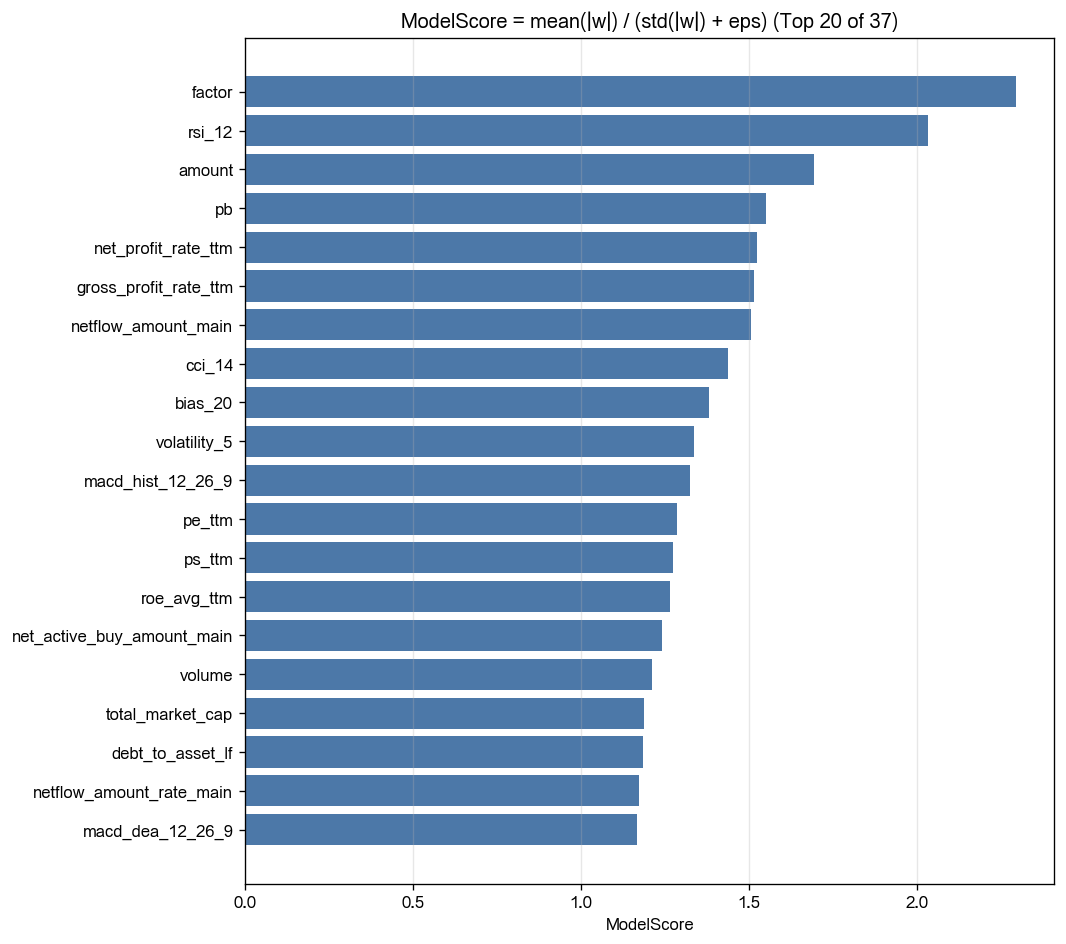
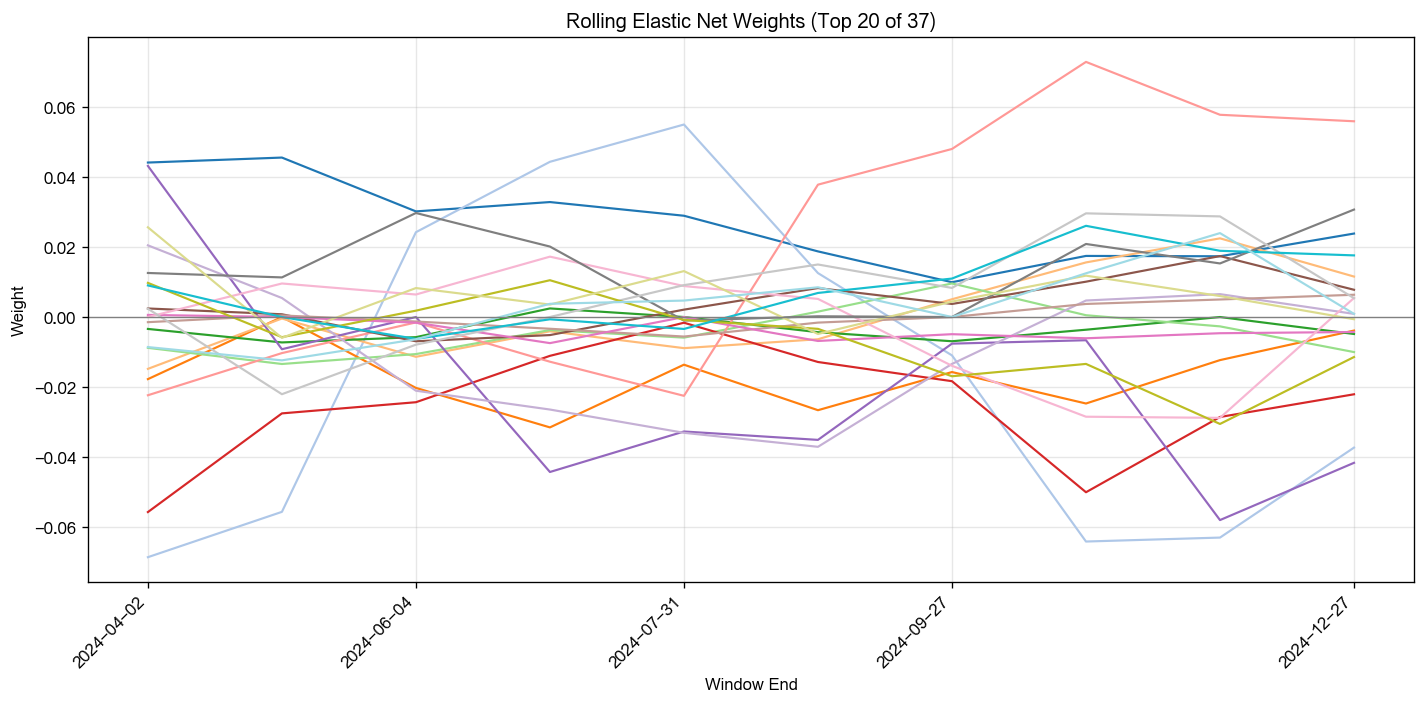
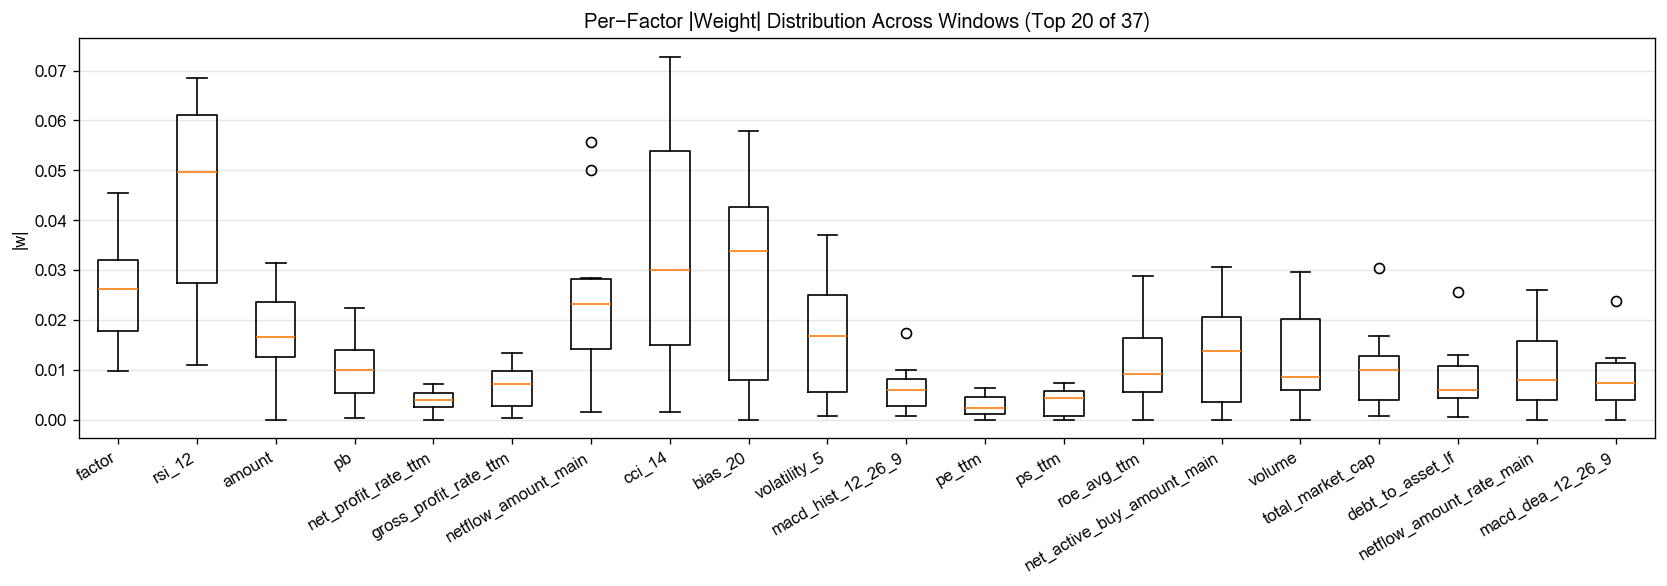
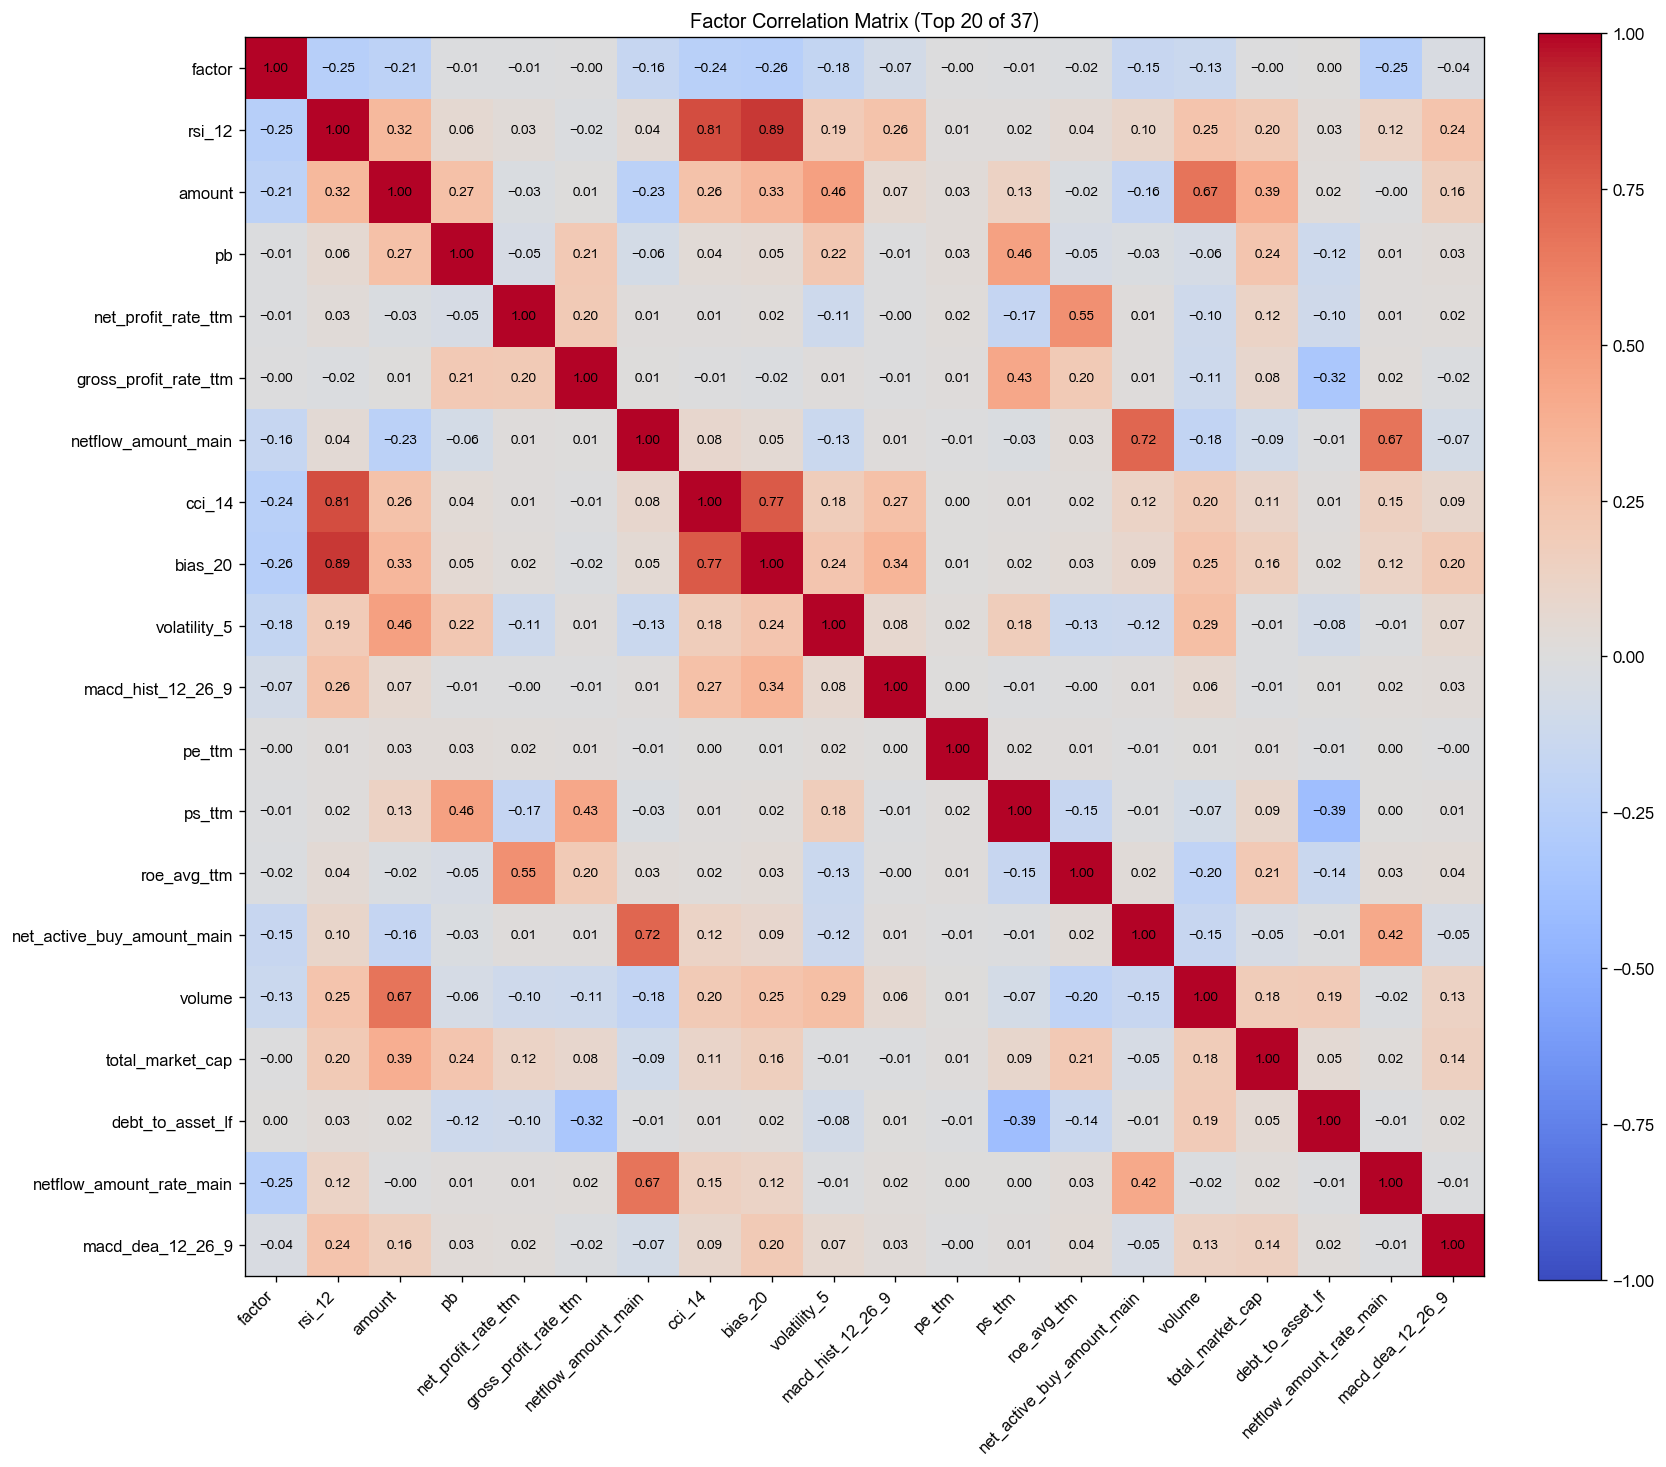

[2026-07-08 15:25:15] [warning  ] 返回的Outputs实例(size=35267973) 大于 64K, 将不会被缓存
[2026-07-08 15:25:15] [info     ] bigalpha_eval.v4 运行完成 [56.346s].


In [1]:
def main(datasources, start_date, end_date):
    """
    AI001_XGBMicrostructureCombo_v1

    用 XGBoost 学习一组有市场含义的高频微观结构特征：
    尾盘价格冲击、价差、深度、订单簿不平衡、成交占比、平均单笔成交额等。

    训练目标为未来一日收益的日内截面 rank，预测值作为单因子输出。
    """
    import gc
    import sys
    import time

    main_t0 = time.time()

    def _rss_mb():
        try:
            import resource

            rss = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
            if sys.platform == "darwin":
                return round(rss / 1024.0 / 1024.0, 2)
            return round(rss / 1024.0, 2)
        except Exception:
            return None

    def _df_mb(df):
        try:
            return round(float(df.memory_usage(deep=True).sum()) / 1024.0 / 1024.0, 2)
        except Exception:
            return None

    def _log(stage, **kwargs):
        elapsed = round(time.time() - main_t0, 2)
        parts = [f"[AI001] {stage}", f"elapsed={elapsed}s"]
        rss = _rss_mb()
        if rss is not None:
            parts.append(f"rss_peak_mb={rss}")
        for key, value in kwargs.items():
            parts.append(f"{key}={value}")
        print(" | ".join(parts), flush=True)

    _log("main_enter", start_date=start_date, end_date=end_date)

    _log("imports_start")
    import numpy as np
    import pandas as pd
    import dai
    _log("xgboost_import_start")
    import xgboost as xgb
    _log("imports_done", xgboost_version=getattr(xgb, "__version__", "unknown"))

    # 官方训练窗口。若本地测试区间早于 2025，则自动截断到测试开始日前，避免本地评估泄漏。
    TRAIN_START = "2021-01-01 00:00:00"
    OFFICIAL_TRAIN_END = "2024-12-31 23:59:59"

    feature_cols = [
        "day_return",
        "tail_return",
        "open_return",
        "tail_amount_share",
        "open_amount_share",
        "tail_impact_ratio",
        "tail_spread_ratio",
        "tail_depth_ratio",
        "tail_trade_value_ratio",
        "day_obi",
        "tail_obi",
        "tail_obi_shift",
        "day_order_imbalance",
        "tail_order_imbalance",
        "tail_order_imbalance_shift",
        "intraday_reversal_pressure",
        "liquidity_vacuum_raw",
    ]

    def month_ranges(start, end):
        cur = pd.Timestamp(start).normalize().replace(day=1)
        end = pd.Timestamp(end).normalize()
        while cur <= end:
            nxt = cur + pd.offsets.MonthBegin(1)
            yield max(cur, pd.Timestamp(start).normalize()), min(nxt - pd.Timedelta(days=1), end)
            cur = nxt

    def build_micro_features(bar1m_table, sd, ed, phase):
        query_t0 = time.time()
        start_ts = pd.Timestamp(sd).normalize()
        end_ts = pd.Timestamp(ed).normalize()
        frames = []
        _log("feature_chunks_start", phase=phase, table=bar1m_table, start=sd, end=ed)
        sql = f"""
        WITH base AS (
            SELECT
                date,
                instrument,
                date_trunc('day', date)::DATE AS trading_day,
                (ask_price1 + bid_price1) / 2.0 AS mid_price,
                (ask_price1 - bid_price1) / ((ask_price1 + bid_price1) / 2.0 + 1e-8) AS rel_spread,
                (
                    COALESCE(bid_volume1, 0) * 1.0 +
                    COALESCE(bid_volume2, 0) * EXP(-0.4) +
                    COALESCE(bid_volume3, 0) * EXP(-0.8) +
                    COALESCE(bid_volume4, 0) * EXP(-1.2) +
                    COALESCE(bid_volume5, 0) * EXP(-1.6)
                ) AS weighted_bid,
                (
                    COALESCE(ask_volume1, 0) * 1.0 +
                    COALESCE(ask_volume2, 0) * EXP(-0.4) +
                    COALESCE(ask_volume3, 0) * EXP(-0.8) +
                    COALESCE(ask_volume4, 0) * EXP(-1.2) +
                    COALESCE(ask_volume5, 0) * EXP(-1.6)
                ) AS weighted_ask,
                (
                    COALESCE(bid_volume1, 0) +
                    COALESCE(bid_volume2, 0) +
                    COALESCE(bid_volume3, 0) +
                    COALESCE(bid_volume4, 0) +
                    COALESCE(bid_volume5, 0) +
                    COALESCE(ask_volume1, 0) +
                    COALESCE(ask_volume2, 0) +
                    COALESCE(ask_volume3, 0) +
                    COALESCE(ask_volume4, 0) +
                    COALESCE(ask_volume5, 0)
                ) AS total_depth,
                (
                    COALESCE(bid_num_orders1, 0) +
                    COALESCE(bid_num_orders2, 0) +
                    COALESCE(bid_num_orders3, 0) +
                    COALESCE(bid_num_orders4, 0) +
                    COALESCE(bid_num_orders5, 0)
                ) AS bid_order_count,
                (
                    COALESCE(ask_num_orders1, 0) +
                    COALESCE(ask_num_orders2, 0) +
                    COALESCE(ask_num_orders3, 0) +
                    COALESCE(ask_num_orders4, 0) +
                    COALESCE(ask_num_orders5, 0)
                ) AS ask_order_count,
                amount,
                deal_number,
                CASE
                    WHEN strftime(date, '%H:%M:%S') >= '09:31:00'
                     AND strftime(date, '%H:%M:%S') <= '10:00:00'
                    THEN 1 ELSE 0
                END AS is_open,
                CASE
                    WHEN strftime(date, '%H:%M:%S') >= '14:30:00'
                     AND strftime(date, '%H:%M:%S') <= '15:00:00'
                    THEN 1 ELSE 0
                END AS is_tail
            FROM {bar1m_table}
            WHERE ask_price1 > 0
              AND bid_price1 > 0
              AND ask_price1 >= bid_price1
        ),
        minute_features AS (
            SELECT
                *,
                (weighted_bid - weighted_ask) / (weighted_bid + weighted_ask + 1e-8) AS obi,
                (bid_order_count - ask_order_count) / (bid_order_count + ask_order_count + 1e-8) AS order_imbalance,
                lag(mid_price, 1) OVER (
                    PARTITION BY instrument, trading_day
                    ORDER BY date
                ) AS prev_mid_price,
                lag(amount, 1) OVER (
                    PARTITION BY instrument, trading_day
                    ORDER BY date
                ) AS prev_amount,
                lag(deal_number, 1) OVER (
                    PARTITION BY instrument, trading_day
                    ORDER BY date
                ) AS prev_deal_number
            FROM base
        ),
        cleaned AS (
            SELECT
                *,
                CASE
                    WHEN amount IS NULL THEN NULL
                    WHEN prev_amount IS NULL THEN amount
                    WHEN amount >= prev_amount THEN amount - prev_amount
                    ELSE amount
                END AS delta_amount,
                CASE
                    WHEN deal_number IS NULL THEN NULL
                    WHEN prev_deal_number IS NULL THEN deal_number
                    WHEN deal_number >= prev_deal_number THEN deal_number - prev_deal_number
                    ELSE deal_number
                END AS delta_deal_number,
                CASE
                    WHEN prev_mid_price > 0 AND mid_price > 0
                    THEN log(mid_price / prev_mid_price)
                    ELSE NULL
                END AS mid_ret
            FROM minute_features
        ),
        per_minute AS (
            SELECT
                *,
                CASE
                    WHEN delta_amount > 0 AND mid_ret IS NOT NULL
                    THEN abs(mid_ret) / (delta_amount + 1.0)
                    ELSE NULL
                END AS impact_per_value,
                CASE
                    WHEN delta_amount > 0 THEN delta_amount
                    ELSE 0.0
                END AS amount_weight,
                CASE
                    WHEN delta_amount > 0 AND delta_deal_number > 0
                    THEN delta_amount / delta_deal_number
                    ELSE NULL
                END AS avg_trade_value
            FROM cleaned
        ),
        daily AS (
            SELECT
                trading_day,
                instrument,
                COUNT(*) AS day_bar_count,
                SUM(is_open) AS open_bar_count,
                SUM(is_tail) AS tail_bar_count,

                ARG_MIN(mid_price, date) AS day_first_mid,
                ARG_MAX(mid_price, date) AS day_last_mid,
                ARG_MIN(mid_price, date) FILTER (WHERE is_open = 1) AS open_first_mid,
                ARG_MAX(mid_price, date) FILTER (WHERE is_open = 1) AS open_last_mid,
                ARG_MIN(mid_price, date) FILTER (WHERE is_tail = 1) AS tail_first_mid,
                ARG_MAX(mid_price, date) FILTER (WHERE is_tail = 1) AS tail_last_mid,

                SUM(amount_weight) AS day_amount,
                SUM(CASE WHEN is_open = 1 THEN amount_weight ELSE 0.0 END) AS open_amount,
                SUM(CASE WHEN is_tail = 1 THEN amount_weight ELSE 0.0 END) AS tail_amount,

                SUM(COALESCE(impact_per_value, 0.0) * amount_weight)
                    / (SUM(amount_weight) + 1e-8) AS day_impact,
                SUM(CASE WHEN is_tail = 1 THEN COALESCE(impact_per_value, 0.0) * amount_weight ELSE 0.0 END)
                    / (SUM(CASE WHEN is_tail = 1 THEN amount_weight ELSE 0.0 END) + 1e-8) AS tail_impact,

                SUM(COALESCE(rel_spread, 0.0) * amount_weight)
                    / (SUM(amount_weight) + 1e-8) AS day_spread,
                SUM(CASE WHEN is_tail = 1 THEN COALESCE(rel_spread, 0.0) * amount_weight ELSE 0.0 END)
                    / (SUM(CASE WHEN is_tail = 1 THEN amount_weight ELSE 0.0 END) + 1e-8) AS tail_spread,

                AVG(total_depth) AS day_depth,
                AVG(CASE WHEN is_tail = 1 THEN total_depth ELSE NULL END) AS tail_depth,

                SUM(COALESCE(avg_trade_value, 0.0) * amount_weight)
                    / (SUM(amount_weight) + 1e-8) AS day_trade_value,
                SUM(CASE WHEN is_tail = 1 THEN COALESCE(avg_trade_value, 0.0) * amount_weight ELSE 0.0 END)
                    / (SUM(CASE WHEN is_tail = 1 THEN amount_weight ELSE 0.0 END) + 1e-8) AS tail_trade_value,

                SUM(COALESCE(obi, 0.0) * amount_weight)
                    / (SUM(amount_weight) + 1e-8) AS day_obi,
                SUM(CASE WHEN is_tail = 1 THEN COALESCE(obi, 0.0) * amount_weight ELSE 0.0 END)
                    / (SUM(CASE WHEN is_tail = 1 THEN amount_weight ELSE 0.0 END) + 1e-8) AS tail_obi,

                SUM(COALESCE(order_imbalance, 0.0) * amount_weight)
                    / (SUM(amount_weight) + 1e-8) AS day_order_imbalance,
                SUM(CASE WHEN is_tail = 1 THEN COALESCE(order_imbalance, 0.0) * amount_weight ELSE 0.0 END)
                    / (SUM(CASE WHEN is_tail = 1 THEN amount_weight ELSE 0.0 END) + 1e-8) AS tail_order_imbalance
            FROM per_minute
            GROUP BY trading_day, instrument
        )
        SELECT
            CAST(trading_day AS DATETIME) AS date,
            instrument,
            day_last_mid AS daily_close,
            day_last_mid / (day_first_mid + 1e-8) - 1.0 AS day_return,
            tail_last_mid / (tail_first_mid + 1e-8) - 1.0 AS tail_return,
            open_last_mid / (open_first_mid + 1e-8) - 1.0 AS open_return,
            tail_amount / (day_amount + 1e-8) AS tail_amount_share,
            open_amount / (day_amount + 1e-8) AS open_amount_share,
            tail_impact / (day_impact + 1e-12) AS tail_impact_ratio,
            tail_spread / (day_spread + 1e-8) AS tail_spread_ratio,
            day_depth / (tail_depth + 1e-8) AS tail_depth_ratio,
            tail_trade_value / (day_trade_value + 1e-8) AS tail_trade_value_ratio,
            day_obi,
            tail_obi,
            tail_obi - day_obi AS tail_obi_shift,
            day_order_imbalance,
            tail_order_imbalance,
            tail_order_imbalance - day_order_imbalance AS tail_order_imbalance_shift,
            -1.0 * (tail_last_mid / (tail_first_mid + 1e-8) - 1.0)
                * log(1.0 + tail_impact / (day_impact + 1e-12))
                * log(1.0 + tail_spread / (day_spread + 1e-8))
                * log(1.0 + day_depth / (tail_depth + 1e-8)) AS intraday_reversal_pressure,
            (
                log(1.0 + tail_impact / (day_impact + 1e-12)) +
                log(1.0 + tail_spread / (day_spread + 1e-8)) +
                log(1.0 + day_depth / (tail_depth + 1e-8))
            ) * log(1.0 + 10.0 * tail_amount / (day_amount + 1e-8)) AS liquidity_vacuum_raw
        FROM daily
        WHERE day_bar_count >= 120
          AND open_bar_count >= 10
          AND tail_bar_count >= 15
          AND day_amount > 0
          AND tail_amount > 0
          AND open_amount > 0
          AND day_first_mid > 0
          AND day_last_mid > 0
          AND open_first_mid > 0
          AND open_last_mid > 0
          AND tail_first_mid > 0
          AND tail_last_mid > 0
          AND day_impact >= 0
          AND tail_impact >= 0
          AND day_spread > 0
          AND tail_spread > 0
          AND day_depth > 0
          AND tail_depth > 0
          AND day_trade_value > 0
          AND tail_trade_value > 0
        """

        for chunk_no, (chunk_start, chunk_end) in enumerate(month_ranges(start_ts, end_ts), 1):
            chunk_t0 = time.time()
            chunk_sd = chunk_start.strftime("%Y-%m-%d 00:00:00")
            chunk_ed = chunk_end.strftime("%Y-%m-%d 23:59:59")
            _log(
                "feature_chunk_query_start",
                phase=phase,
                chunk=chunk_no,
                start=chunk_sd,
                end=chunk_ed,
            )
            chunk_df = dai.query(
                sql,
                filters={"date": [chunk_sd, chunk_ed]},
                compression=True,
            ).df()
            frames.append(chunk_df)
            _log(
                "feature_chunk_query_done",
                phase=phase,
                chunk=chunk_no,
                rows=len(chunk_df),
                cols=len(chunk_df.columns),
                seconds=round(time.time() - chunk_t0, 2),
                df_mb=_df_mb(chunk_df),
            )

        if frames:
            df = pd.concat(frames, ignore_index=True)
        else:
            df = pd.DataFrame()
        _log(
            "feature_chunks_done",
            phase=phase,
            table=bar1m_table,
            rows=len(df),
            cols=len(df.columns),
            seconds=round(time.time() - query_t0, 2),
            df_mb=_df_mb(df),
        )
        df["date"] = pd.to_datetime(df["date"])
        df["instrument"] = df["instrument"].astype(str)
        df = df.sort_values(["instrument", "date"]).reset_index(drop=True)
        if len(df) > 0:
            _log(
                "feature_format_done",
                phase=phase,
                table=bar1m_table,
                rows=len(df),
                date_min=df["date"].min(),
                date_max=df["date"].max(),
                df_mb=_df_mb(df),
            )
        else:
            _log("feature_format_done", phase=phase, table=bar1m_table, rows=0)
        return df

    def add_ranked_features(df):
        rank_t0 = time.time()
        _log("rank_features_start", rows=len(df), df_mb=_df_mb(df))
        df = df.copy()
        for col in feature_cols:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            df[col] = df[col].replace([np.inf, -np.inf], np.nan)
            df[col] = df.groupby("date", group_keys=False)[col].transform(
                lambda x: x.rank(pct=True) - 0.5
            )
        _log("rank_features_done", rows=len(df), seconds=round(time.time() - rank_t0, 2), df_mb=_df_mb(df))
        return df

    test_start = pd.to_datetime(start_date)
    official_train_end = pd.to_datetime(OFFICIAL_TRAIN_END)
    train_end = min(official_train_end, test_start - pd.Timedelta(days=1))
    train_start = pd.to_datetime(TRAIN_START)
    _log("train_window_resolved", train_start=train_start, train_end=train_end)

    if train_end <= train_start:
        raise ValueError("训练区间为空：请检查 start_date 与训练窗口设置")

    _log("train_features_start")
    train_df = build_micro_features(
        "bigalpha_2026_stock_bar1m",
        train_start.strftime("%Y-%m-%d 00:00:00"),
        train_end.strftime("%Y-%m-%d 23:59:59"),
        "train",
    )
    _log("train_features_done", rows=len(train_df), df_mb=_df_mb(train_df))

    label_t0 = time.time()
    _log("train_label_start", rows=len(train_df))
    train_df["next_close"] = train_df.groupby("instrument")["daily_close"].shift(-1)
    train_df["raw_label"] = train_df["next_close"] / train_df["daily_close"] - 1.0
    train_df["label"] = train_df.groupby("date", group_keys=False)["raw_label"].transform(
        lambda x: x.rank(pct=True) - 0.5
    )
    train_df = add_ranked_features(train_df)
    train_df = train_df.dropna(subset=["label"]).reset_index(drop=True)
    _log(
        "train_label_done",
        rows=len(train_df),
        seconds=round(time.time() - label_t0, 2),
        label_nan=int(train_df["label"].isna().sum()),
        df_mb=_df_mb(train_df),
    )

    fit_t0 = time.time()
    _log("xgboost_fit_start", rows=len(train_df), features=len(feature_cols))
    model = xgb.XGBRegressor(
        n_estimators=90,
        max_depth=3,
        learning_rate=0.045,
        subsample=0.80,
        colsample_bytree=0.80,
        min_child_weight=80,
        reg_alpha=0.5,
        reg_lambda=20.0,
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=-1,
        random_state=20260706,
    )
    model.fit(train_df[feature_cols], train_df["label"])
    _log("xgboost_fit_done", seconds=round(time.time() - fit_t0, 2))

    del train_df
    gc.collect()
    _log("train_objects_released")

    _log("test_features_start")
    test_df = build_micro_features(datasources["bar1m"], start_date, end_date, "test")
    _log("test_features_done", rows=len(test_df), df_mb=_df_mb(test_df))
    test_df = add_ranked_features(test_df)
    _log("predict_start", rows=len(test_df))
    test_df["factor"] = model.predict(test_df[feature_cols])
    _log(
        "predict_done",
        rows=len(test_df),
        factor_nan=int(test_df["factor"].isna().sum()),
        df_mb=_df_mb(test_df),
    )

    factor_data = test_df[["date", "instrument", "factor"]].copy()
    factor_data["date"] = pd.to_datetime(factor_data["date"])
    factor_data["instrument"] = factor_data["instrument"].astype(str)
    factor_data["factor"] = pd.to_numeric(factor_data["factor"], errors="coerce").replace([np.inf, -np.inf], np.nan)

    pool_t0 = time.time()
    _log("stock_pool_query_start")
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]},
    ).df()
    _log(
        "stock_pool_query_done",
        rows=len(stk_pool),
        seconds=round(time.time() - pool_t0, 2),
        df_mb=_df_mb(stk_pool),
    )
    stk_pool["date"] = pd.to_datetime(stk_pool["date"])
    stk_pool["instrument"] = stk_pool["instrument"].astype(str)

    merge_t0 = time.time()
    _log("merge_pool_start", factor_rows=len(factor_data), pool_rows=len(stk_pool))
    result = pd.merge(stk_pool, factor_data, how="left", on=["date", "instrument"])
    result = result[["date", "instrument", "factor"]].copy()
    result["factor"] = pd.to_numeric(result["factor"], errors="coerce")
    result["factor"] = result["factor"].replace([np.inf, -np.inf], np.nan)
    missing_before = int(result["factor"].isna().sum())
    result["factor"] = result.groupby("date", group_keys=False)["factor"].transform(
        lambda x: x.fillna(x.median())
    )
    result["factor"] = result["factor"].fillna(0.0).astype("float32")
    missing_after = int(result["factor"].isna().sum())
    result = result.sort_values(["date", "instrument"], kind="mergesort").reset_index(drop=True)
    _log(
        "main_done",
        rows=len(result),
        missing_before_fill=missing_before,
        missing_after_fill=missing_after,
        seconds_merge=round(time.time() - merge_t0, 2),
        total_seconds=round(time.time() - main_t0, 2),
        df_mb=_df_mb(result),
    )
    return result


if __name__ == "__main__":
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    datasources = {
        "bar1m": "bigalpha_2026_stock_bar1m",
        "financial": "bigalpha_2026_financial",
    }
    start_date = "2024-01-01 00:00:00"
    end_date = "2024-12-31 23:59:59"

    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)
    logger.info("因子计算完成", rows=len(factor_data))

    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={"date": [start_date, end_date]},
        compression=True,
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
